<a href="https://colab.research.google.com/github/edwardcalvinvazc-maker/MLSamples/blob/main/KNN_imputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import pandas as pd
import numpy as np
cdf = pd.read_csv('/content/dirty_cafe_sales.csv')
cdf

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [106]:
# Standardize all string representations of missing values to np.nan
# This includes 'UNKNOWN' and 'ERROR' strings that indicate missing data.

# For numerical columns that might contain 'ERROR' strings (like 'Total Spent')
# Convert to numeric, coercing errors to NaN
for col in ['Total Spent', 'Quantity', 'Price Per Unit']:
    if col in cdf.columns:
        cdf[col] = pd.to_numeric(cdf[col], errors='coerce')

# For categorical columns that might contain 'UNKNOWN' or 'ERROR' strings
# Replace these strings with np.nan
# Note: 'Item' column is handled separately by LabelEncoder after this initial cleanup.
for col in ['Payment Method', 'Location']:
    if col in cdf.columns:
        cdf[col] = cdf[col].replace(['UNKNOWN', 'ERROR'], np.nan)

print("Missing values after initial cleaning:")
print(cdf.isnull().sum())

Missing values after initial cleaning:
Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     159
dtype: int64


In [107]:
cdf.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,479
Price Per Unit,533
Total Spent,502
Payment Method,3178
Location,3961
Transaction Date,159


In [108]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Consolidate 'UNKNOWN' and 'ERROR' strings with np.nan first
cdf['Item'] = cdf['Item'].replace(['UNKNOWN', 'ERROR'], np.nan)

# Handle NaN values by converting the column to string 'Missing' for LabelEncoder
# LabelEncoder requires a sequence of values without nulls
cdf['Item_encoded'] = le.fit_transform(cdf['Item'].fillna('Missing').astype(str))

print("First 10 rows of encoded data:")
print(cdf[['Item', 'Item_encoded']].head(10))

print("\nLabelEncoder mapping for Item_encoded:")
# Create a dictionary of the mapping for better understanding
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

First 10 rows of encoded data:
       Item  Item_encoded
0    Coffee             1
1      Cake             0
2    Cookie             2
3     Salad             5
4    Coffee             1
5  Smoothie             7
6       NaN             4
7  Sandwich             6
8       NaN             4
9  Sandwich             6

LabelEncoder mapping for Item_encoded:
{'Cake': np.int64(0), 'Coffee': np.int64(1), 'Cookie': np.int64(2), 'Juice': np.int64(3), 'Missing': np.int64(4), 'Salad': np.int64(5), 'Sandwich': np.int64(6), 'Smoothie': np.int64(7), 'Tea': np.int64(8)}


In [109]:
from sklearn.impute import SimpleImputer
# The missing_values parameter should correspond to the integer LabelEncoder assigns to 'Missing'.
# Based on previous output, 'NaN' (which will now be 'Missing')
simp = SimpleImputer(strategy='most_frequent', missing_values=4)
cdf['Item_encoded'] = simp.fit_transform(cdf[['Item_encoded']])

In [110]:
cdf[['Item', 'Item_encoded']]

,Item,Item_encoded
0,Coffee,1
1,Cake,0
2,Cookie,2
3,Salad,5
4,Coffee,1
...,...,...
9995,Coffee,1
9996,NaN,3
9997,Coffee,1
9998,Cookie,2


In [111]:
from sklearn.impute import KNNImputer
knn = KNNImputer(n_neighbors=3,missing_values=np.nan)
en_cdf = knn.fit_transform(en_cdf)


In [112]:
# Convert the numpy array `en_cdf` back to a DataFrame
# Assuming en_cdf now contains 'Item_encoded', 'Quantity', 'Price Per Unit', and 'Total Spent'
en_cdf_df = pd.DataFrame(en_cdf, columns=['Item_encoded', 'Quantity', 'Price Per Unit', 'Total Spent'])

# Apply LabelEncoder to the 'Quantity' column to create 'Quantity_encoded'
# This treats each unique numerical quantity as a distinct category
from sklearn.preprocessing import LabelEncoder
le_quantity = LabelEncoder()
en_cdf_df['Quantity_encoded'] = le_quantity.fit_transform(en_cdf_df['Quantity'])

print("DataFrame with Quantity_encoded:")
display(en_cdf_df.head())

print("\nLabelEncoder mapping for Quantity_encoded:")
quantity_label_mapping = dict(zip(le_quantity.classes_, le_quantity.transform(le_quantity.classes_)))
print(quantity_label_mapping)

# Update en_cdf to be this new DataFrame
en_cdf = en_cdf_df
en_cdf.drop(columns=['Quantity'], inplace=True)
en_cdf.head()

DataFrame with Quantity_encoded:


,Item_encoded,Quantity,Price Per Unit,Total Spent,Quantity_encoded
0,1.0,2.0,2.0,2.0,2
1,0.0,3.0,3.0,7.0,3
2,2.0,1.0,1.0,7.0,0
3,5.0,5.0,5.0,2.0,5
4,1.0,2.0,2.0,2.0,2



LabelEncoder mapping for Quantity_encoded:
{np.float64(1.0): np.int64(0), np.float64(1.5): np.int64(1), np.float64(2.0): np.int64(2), np.float64(3.0): np.int64(3), np.float64(4.0): np.int64(4), np.float64(5.0): np.int64(5)}


,Item_encoded,Price Per Unit,Total Spent,Quantity_encoded
0,1.0,2.0,2.0,2
1,0.0,3.0,7.0,3
2,2.0,1.0,7.0,0
3,5.0,5.0,2.0,5
4,1.0,2.0,2.0,2


In [113]:
en_cdf.isnull().sum()

,0
Item_encoded,0
Price Per Unit,0
Total Spent,0
Quantity_encoded,0


In [114]:
en_cdf['Price Per Unit'] = cdf ['Price Per Unit']
knn = KNNImputer(n_neighbors=3,missing_values=np.nan)
en_cdf = knn.fit_transform(en_cdf)
en_cdf

array([[1., 2., 2., 2.],
       [0., 3., 7., 3.],
       [2., 1., 7., 0.],
       ...,
       [1., 2., 7., 2.],
       [2., 1., 4., 0.],
       [6., 4., 4., 4.]])

In [116]:
en_cdf = pd.DataFrame(en_cdf, columns=['Item_encoded', 'Quantity_encoded', 'Price Per Unit', 'Total Spent'])
en_cdf.isnull().sum()

,0
Item_encoded,0
Quantity_encoded,0
Price Per Unit,0
Total Spent,0


In [118]:
from sklearn.preprocessing import LabelEncoder

columns_to_encode = ['Price Per Unit', 'Total Spent']

for col in columns_to_encode:
    if col in en_cdf.columns:
        le_col = LabelEncoder()
        en_cdf[f'encoded_{col.replace(" ", "_")}'] = le_col.fit_transform(en_cdf[col])
        print(f"LabelEncoder mapping for encoded_{col.replace(" ", "_")}:")
        print(dict(zip(le_col.classes_, le_col.transform(le_col.classes_))))
        # Drop the original column after encoding
        en_cdf.drop(columns=[col], inplace=True)

print("\nUpdated en_cdf with all encoded columns:")
display(en_cdf.head())


Updated en_cdf with all encoded columns:


,Item_encoded,Quantity_encoded,encoded_Price_Per_Unit,encoded_Total_Spent
0,1.0,2.0,2,2
1,0.0,3.0,7,3
2,2.0,1.0,7,0
3,5.0,5.0,2,5
4,1.0,2.0,2,2


In [119]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

# Create a temporary DataFrame to hold the new columns for imputation
temp_impute_df = pd.DataFrame(index=cdf.index)

# Process 'Payment Method' column from cdf
le_payment_method = LabelEncoder()
temp_impute_df['encoded_Payment_Method'] = le_payment_method.fit_transform(cdf['Payment Method'].fillna('Missing').astype(str))
print("LabelEncoder mapping for encoded_Payment_Method:")
print(dict(zip(le_payment_method.classes_, le_payment_method.transform(le_payment_method.classes_))))

# Process 'Location' column from cdf
le_location = LabelEncoder()
temp_impute_df['encoded_Location'] = le_location.fit_transform(cdf['Location'].fillna('Missing').astype(str))
print("\nLabelEncoder mapping for encoded_Location:")
print(dict(zip(le_location.classes_, le_location.transform(le_location.classes_))))

# Process 'Transaction Date' column from cdf
# Convert to datetime, coercing errors to NaT (which are NaN for datetime)
cdf['Transaction Date'] = pd.to_datetime(cdf['Transaction Date'], errors='coerce')
# Extract day of the year as a numerical feature. NaT will result in NaN.
temp_impute_df['transaction_dayofyear'] = cdf['Transaction Date'].dt.dayofyear

LabelEncoder mapping for encoded_Payment_Method:
{'Cash': np.int64(0), 'Credit Card': np.int64(1), 'Digital Wallet': np.int64(2), 'Missing': np.int64(3)}

LabelEncoder mapping for encoded_Location:
{'In-store': np.int64(0), 'Missing': np.int64(1), 'Takeaway': np.int64(2)}


Now, we apply `KNNImputer` to these newly prepared columns. The `KNNImputer` will effectively fill in the `NaN` values in `transaction_dayofyear` and any other potential NaNs that might arise from other processing steps, using the relationships between the columns.

In [120]:
# Apply KNNImputer to the temporary DataFrame with newly processed columns
knn_final_cols_imputer = KNNImputer(n_neighbors=3, missing_values=np.nan)
imputed_new_cols_array = knn_final_cols_imputer.fit_transform(temp_impute_df)

# Convert the imputed numpy array back to a DataFrame
imputed_new_cols_df = pd.DataFrame(imputed_new_cols_array,
                                   columns=['encoded_Payment_Method', 'encoded_Location', 'encoded_Transaction_DayOfYear'])

# Concatenate these newly imputed and encoded columns to the existing en_cdf
en_cdf = pd.concat([en_cdf, imputed_new_cols_df], axis=1)

print("\nUpdated en_cdf with all processed columns:")
display(en_cdf.head())
print("\nChecking for missing values in the final en_cdf:")
print(en_cdf.isnull().sum())


Updated en_cdf with all processed columns:


,Item_encoded,Quantity_encoded,encoded_Price_Per_Unit,encoded_Total_Spent,encoded_Payment_Method,encoded_Location,encoded_Transaction_DayOfYear
0,1.0,2.0,2,2,1.0,2.0,251.0
1,0.0,3.0,7,3,0.0,0.0,136.0
2,2.0,1.0,7,0,1.0,0.0,200.0
3,5.0,5.0,2,5,3.0,1.0,117.0
4,1.0,2.0,2,2,2.0,0.0,162.0



Checking for missing values in the final en_cdf:
Item_encoded                     0
Quantity_encoded                 0
encoded_Price_Per_Unit           0
encoded_Total_Spent              0
encoded_Payment_Method           0
encoded_Location                 0
encoded_Transaction_DayOfYear    0
dtype: int64


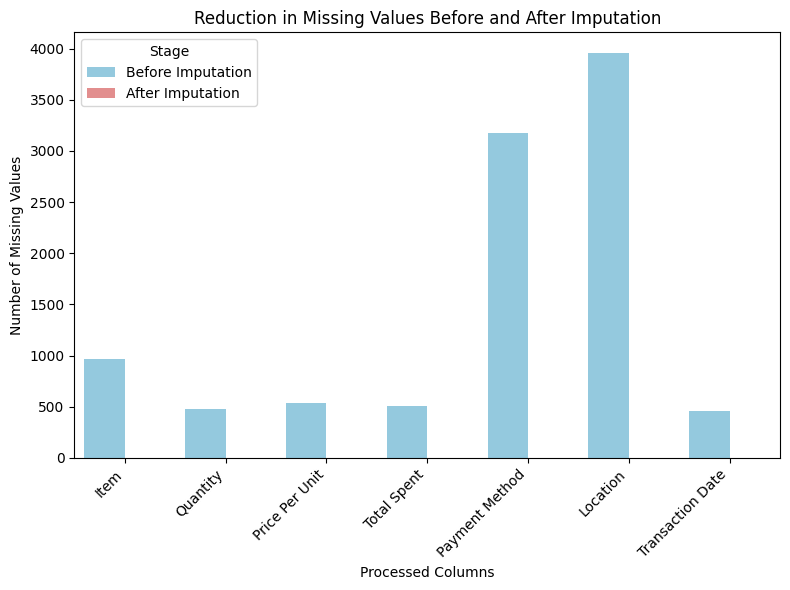


Confirmation: Total missing values in the final en_cdf DataFrame are: 0


In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get missing values from the cdf DataFrame after initial cleaning (before imputation)
initial_missing_cdf = cdf.isnull().sum()

# Define the columns that were processed and their corresponding final names in en_cdf
# We'll map the original cdf column names to the plot labels.
columns_to_track = {
    'Item': 'Item',
    'Quantity': 'Quantity',
    'Price Per Unit': 'Price Per Unit',
    'Total Spent': 'Total Spent',
    'Payment Method': 'Payment Method',
    'Location': 'Location',
    'Transaction Date': 'Transaction Date'
}

plot_data = []

for original_col_name, plot_label in columns_to_track.items():
    # Missing values 'Before Imputation' from cdf
    missing_before = initial_missing_cdf.get(original_col_name, 0)
    plot_data.append({'Column': plot_label, 'Missing_Count': missing_before, 'Stage': 'Before Imputation'})

    # Missing values 'After Imputation' (which are all 0 in en_cdf)
    plot_data.append({'Column': plot_label, 'Missing_Count': 0, 'Stage': 'After Imputation'})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Column', y='Missing_Count', hue='Stage', data=df_plot, palette={'Before Imputation': 'skyblue', 'After Imputation': 'lightcoral'})
plt.title('Reduction in Missing Values Before and After Imputation')
plt.xlabel('Processed Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stage')
plt.tight_layout()
plt.show()

print(f"\nConfirmation: Total missing values in the final en_cdf DataFrame are: {en_cdf.isnull().sum().sum()}")